# Notebook 6 - Train, Tune, and Evaluate

## Evaluation protocol

1. Compare against a `most_frequent` dummy baseline.
2. Tune class-weighted logistic regression using validation PR-AUC.
3. Select the classification threshold on validation F1.
4. Refit the chosen estimator on train + validation.
5. Touch the test set once, at the end.

PR-AUC is the primary selection metric because late orders are the minority class. Accuracy is reported only as supporting information.

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
ARTIFACTS = ROOT / "artifacts"
FIGURES = ROOT / "figures"
REPORTS = ROOT / "reports"
for folder in [ARTIFACTS, FIGURES, REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)
print(f"Task root: {ROOT.resolve()}")

Task root: C:\Users\moath\Desktop\MLOPS\MLOps_Task1_Rand_Salem\MLOps-Qafza-2026\Tasks\Task-02


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy import sparse
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)

def load_split(name):
    X = sparse.load_npz(ARTIFACTS / f"05_X_{name}.npz")
    y = np.load(ARTIFACTS / f"05_y_{name}.npy")
    return X, y

X_train, y_train = load_split("train")
X_validation, y_validation = load_split("validation")
print("Loaded train and validation. Test remains unopened.")

Loaded train and validation. Test remains unopened.


In [3]:
def metric_dict(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, predictions)),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
    }

## 1. Simple baseline

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_validation_probability = baseline.predict_proba(X_validation)[:, 1]
baseline_validation_metrics = metric_dict(y_validation, baseline_validation_probability)
pd.DataFrame([baseline_validation_metrics], index=["dummy_most_frequent"])

,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc
dummy_most_frequent,0.946579,0.5,0.0,0.0,0.0,0.053421,0.5


## 2. Tune the model on validation PR-AUC

In [5]:
tuning_rows = []
models = {}
for C in [0.01, 0.1, 1.0, 10.0]:
    model = LogisticRegression(
        C=C,
        class_weight="balanced",
        solver="liblinear",
        max_iter=1500,
        random_state=42,
    )
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_validation)[:, 1]
    metrics = metric_dict(y_validation, probability)
    tuning_rows.append({"C": C, **metrics})
    models[C] = model

tuning_results = pd.DataFrame(tuning_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
best_C = float(tuning_results.loc[0, "C"])
best_model = models[best_C]
print("Best C by validation PR-AUC:", best_C)
tuning_results

Best C by validation PR-AUC: 0.01


,C,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc
0,0.01,0.693642,0.698412,0.114575,0.703752,0.197066,0.155313,0.773446
1,0.10,0.693504,0.698339,0.114526,0.703752,0.196994,0.154122,0.770270
2,1.00,0.693711,0.700889,0.115247,0.708926,0.198263,0.153825,0.768691
3,10.00,0.692951,0.700488,0.114981,0.708926,0.197870,0.153817,0.768404


## 3. Tune the decision threshold using validation F1

In [6]:
validation_probability = best_model.predict_proba(X_validation)[:, 1]
threshold_rows = []
for threshold in np.linspace(0.10, 0.90, 81):
    predictions = (validation_probability >= threshold).astype(int)
    threshold_rows.append({
        "threshold": float(threshold),
        "f1": float(f1_score(y_validation, predictions, zero_division=0)),
        "precision": float(precision_score(y_validation, predictions, zero_division=0)),
        "recall": float(recall_score(y_validation, predictions, zero_division=0)),
    })
threshold_results = pd.DataFrame(threshold_rows).sort_values(["f1", "recall"], ascending=False)
best_threshold = float(threshold_results.iloc[0]["threshold"])
print("Selected validation threshold:", best_threshold)
threshold_results.head(10)

Selected validation threshold: 0.67


,threshold,f1,precision,recall
57,0.67,0.252612,0.194678,0.359638
56,0.66,0.252352,0.188498,0.381630
58,0.68,0.247966,0.196809,0.335058
55,0.65,0.247874,0.180425,0.395860
54,0.64,0.244222,0.173889,0.410091
59,0.69,0.241149,0.199830,0.304010
53,0.63,0.240497,0.167601,0.425614
60,0.70,0.237785,0.204864,0.283312
52,0.62,0.236980,0.162356,0.438551
51,0.61,0.233278,0.156499,0.457956


## 4. Final fit and one-time test evaluation

In [7]:
X_test, y_test = load_split("test")  # First and only test access.
X_train_validation = sparse.vstack([X_train, X_validation], format="csr")
y_train_validation = np.concatenate([y_train, y_validation])

final_baseline = DummyClassifier(strategy="most_frequent").fit(X_train_validation, y_train_validation)
final_model = LogisticRegression(
    C=best_C,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1500,
    random_state=42,
).fit(X_train_validation, y_train_validation)

baseline_test_probability = final_baseline.predict_proba(X_test)[:, 1]
model_test_probability = final_model.predict_proba(X_test)[:, 1]

test_results = pd.DataFrame([
    {"model": "Dummy most-frequent", **metric_dict(y_test, baseline_test_probability, 0.5)},
    {"model": "Class-weighted logistic regression", **metric_dict(y_test, model_test_probability, best_threshold)},
])
test_results

,model,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc
0,Dummy most-frequent,0.933868,0.500000,0.000000,0.000000,0.000000,0.066132,0.500000
1,Class-weighted logistic regression,0.772787,0.561338,0.103437,0.317659,0.156057,0.120844,0.682704


## 5. Confusion matrix and saved artifacts

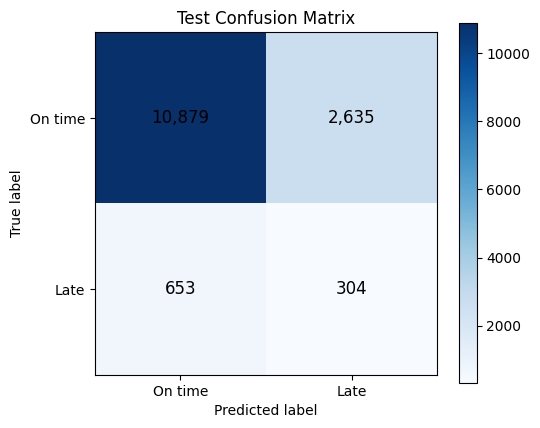

Saved final model and results summary.


{'primary_metric': 'PR-AUC',
 'best_C': 0.01,
 'selected_threshold': 0.67,
 'test_touched_once': True,
 'test_results': [{'model': 'Dummy most-frequent',
   'accuracy': 0.9338677354709419,
   'balanced_accuracy': 0.5,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'pr_auc': 0.06613226452905811,
   'roc_auc': 0.5},
  {'model': 'Class-weighted logistic regression',
   'accuracy': 0.7727869532167784,
   'balanced_accuracy': 0.5613381857647064,
   'precision': 0.10343654304185097,
   'recall': 0.3176593521421108,
   'f1': 0.15605749486652978,
   'pr_auc': 0.12084386762284294,
   'roc_auc': 0.6827044487631465}]}

In [8]:
test_predictions = (model_test_probability >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
image = ax.imshow(cm, cmap="Blues")
for (row, col), value in np.ndenumerate(cm):
    ax.text(col, row, f"{value:,}", ha="center", va="center", fontsize=12)
ax.set(
    title="Test Confusion Matrix",
    xlabel="Predicted label",
    ylabel="True label",
    xticks=[0, 1], yticks=[0, 1],
    xticklabels=["On time", "Late"], yticklabels=["On time", "Late"],
)
fig.colorbar(image, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES / "06_test_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

joblib.dump(final_model, ARTIFACTS / "06_logistic_regression.joblib")
tuning_results.to_csv(REPORTS / "06_validation_tuning.csv", index=False)
threshold_results.sort_values("threshold").to_csv(REPORTS / "06_threshold_tuning.csv", index=False)
test_results.to_csv(REPORTS / "06_test_results.csv", index=False)

summary = {
    "primary_metric": "PR-AUC",
    "best_C": best_C,
    "selected_threshold": best_threshold,
    "test_touched_once": True,
    "test_results": test_results.to_dict(orient="records"),
}
(REPORTS / "06_results_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Saved final model and results summary.")
summary